# Accumulated Local Effects

In [2]:
from copy import deepcopy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.datasets import load_diabetes

## Alibi

In [3]:
from sklearn.ensemble import RandomForestRegressor

X, y = load_diabetes(return_X_y=True)
rf = RandomForestRegressor(random_state=42).fit(X, y)

In [9]:
from alibi.explainers import ALE

In [10]:
ale = ALE(rf.predict)
exp = ale.explain(X)

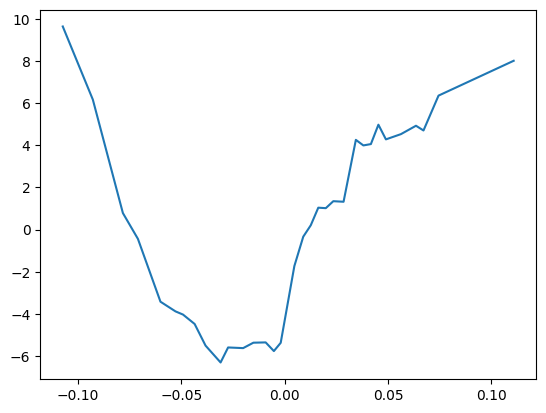

In [26]:
plt.plot(exp.data['feature_values'][0], exp.data['ale_values'][0])

array([[<AxesSubplot: xlabel='f_0', ylabel='ALE'>,
        <AxesSubplot: xlabel='f_1', ylabel='ALE'>,
        <AxesSubplot: xlabel='f_2', ylabel='ALE'>],
       [<AxesSubplot: xlabel='f_3', ylabel='ALE'>,
        <AxesSubplot: xlabel='f_4', ylabel='ALE'>,
        <AxesSubplot: xlabel='f_5', ylabel='ALE'>],
       [<AxesSubplot: xlabel='f_6', ylabel='ALE'>,
        <AxesSubplot: xlabel='f_7', ylabel='ALE'>,
        <AxesSubplot: xlabel='f_8', ylabel='ALE'>],
       [<AxesSubplot: xlabel='f_9', ylabel='ALE'>, None, None]],
      dtype=object)

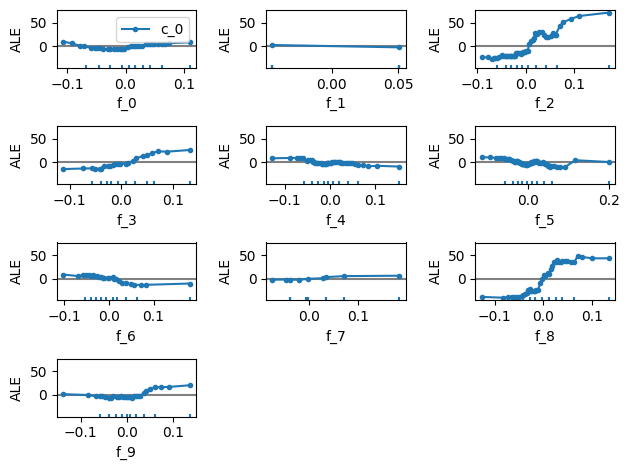

In [18]:
from alibi.explainers import plot_ale
plt.Figure(figsize=(19,15))
plot_ale(exp)

In [139]:
exp.feature_values[0]

array([-0.10722563, -0.09269548, -0.07816532, -0.07090025, -0.06000263,
       -0.05273755, -0.04910502, -0.04349109, -0.0382074 , -0.03094232,
       -0.02730979, -0.02004471, -0.01509125, -0.00914709, -0.00518432,
       -0.00188202,  0.0047226 ,  0.0090156 ,  0.01264814,  0.01628068,
        0.01991321,  0.02354575,  0.02849921,  0.03444337,  0.03807591,
        0.04170844,  0.04534098,  0.04897352,  0.0562386 ,  0.06350368,
        0.06713621,  0.07440129,  0.11072668])

In [140]:
np.array(features_averages[0][1])

array([-0.10359309, -0.09632802, -0.08906294, -0.08179786, -0.07453279,
       -0.06726771, -0.06000263, -0.05273755, -0.04547248, -0.0382074 ,
       -0.03094232, -0.02367725, -0.01641217, -0.00914709, -0.00188202,
        0.00538306,  0.01264814,  0.01991321,  0.02717829,  0.03444337,
        0.04170844,  0.04897352,  0.0562386 ,  0.06350368,  0.07076875,
        0.07803383,  0.08529891,  0.09256398,  0.1034616 ])

In [141]:
total_average, exp.constant_value

(152.11445701357465, 152.11445701357465)

In [142]:
exp.ale_values[0]

array([[ 9.63690115],
       [ 6.16815115],
       [ 0.78243687],
       [-0.44256313],
       [-3.4239917 ],
       [-3.8834917 ],
       [-4.03492028],
       [-4.48047583],
       [-5.50812289],
       [-6.30812289],
       [-5.59545622],
       [-5.62663269],
       [-5.36948984],
       [-5.35548984],
       [-5.7671565 ],
       [-5.37429936],
       [-1.73013269],
       [-0.33840856],
       [ 0.20302002],
       [ 1.03775686],
       [ 1.01502958],
       [ 1.34586292],
       [ 1.31919625],
       [ 4.25633911],
       [ 3.99233911],
       [ 4.05586852],
       [ 4.97586852],
       [ 4.27950488],
       [ 4.52839377],
       [ 4.92608608],
       [ 4.7014707 ],
       [ 6.35608608],
       [ 8.009163  ]])

In [144]:
np.cumsum(np.array(features_averages[0][0]))

array([  0.05833333,  -5.17166667,  -7.17166667, -10.14880952,
       -11.76714286, -12.10047619, -14.77683983, -14.22383983,
       -14.56071483, -16.26659718, -15.11023354, -15.04823354,
       -14.8103764 , -15.1903764 , -12.78883794, -10.43963794,
       -10.51997127, -10.64597127,  -7.52739984,  -6.8045427 ,
        -6.34528344,  -7.14368344,  -6.41701678,  -7.60701678,
        -4.18601678,  -4.44601678,  -4.48268344,  -5.28768344,
        -4.80268344])

## Manual Implementation

In [27]:
from sklearn.ensemble import RandomForestRegressor

In [32]:
X, y = load_diabetes(return_X_y=True)
rf = RandomForestRegressor(random_state=42).fit(X, y)

In [150]:
features = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

n_splits = 50
total_average = np.mean(rf.predict(X))

features_averages = {}
for feature in tqdm(features):
    features_averages[feature] = ([], [])

    aux = np.unique(X[:, feature])
    aux.sort()

    t = int(np.ceil(len(aux) / n_splits))

    for i in range(int(len(aux) / t)):
        if (i+1)*t >= len(aux):
            end_point = -1
        else:
            end_point = (i+1)*t

        start = aux[i*t]
        end = aux[end_point]

        if start == end:
            continue

        X_greater, X_smaller = deepcopy(X), deepcopy(X)
        
        sections = np.where((X_greater[:, feature] >= start)&(X_greater[:, feature] < end))

        X_greater[sections, feature] = end
        X_smaller[sections, feature] = start

        features_averages[feature][0].append((np.mean(rf.predict(X_greater[sections[0], :]) - rf.predict(X_smaller[sections[0], :]))))
        features_averages[feature][1].append((start + end) / 2)

100%|██████████| 10/10 [00:03<00:00,  2.60it/s]


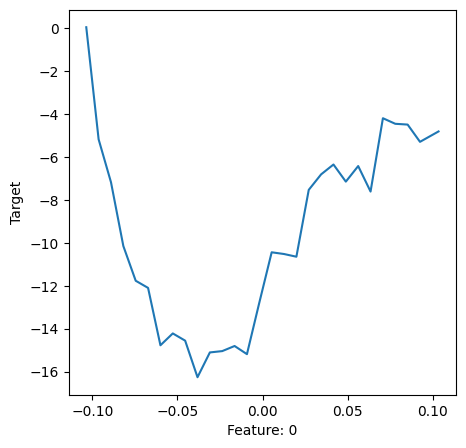

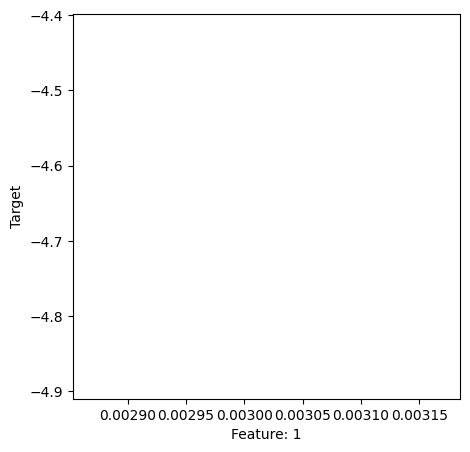

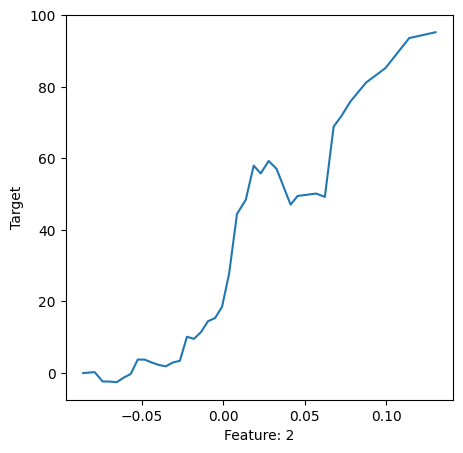

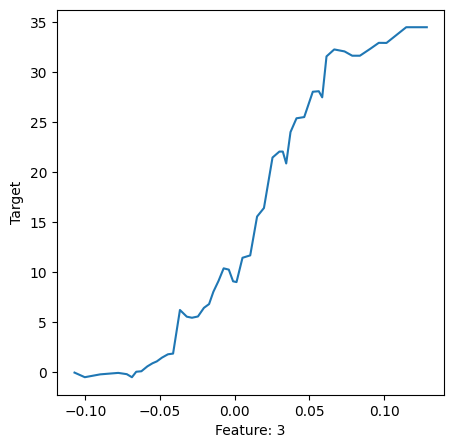

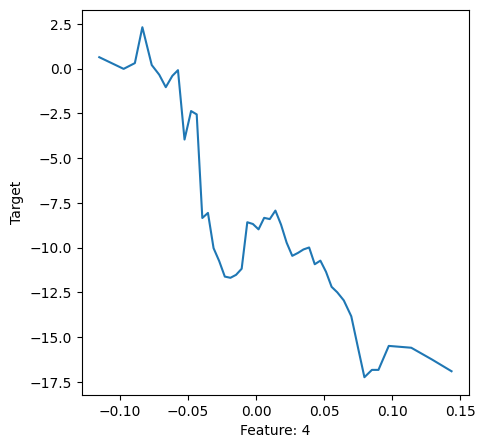

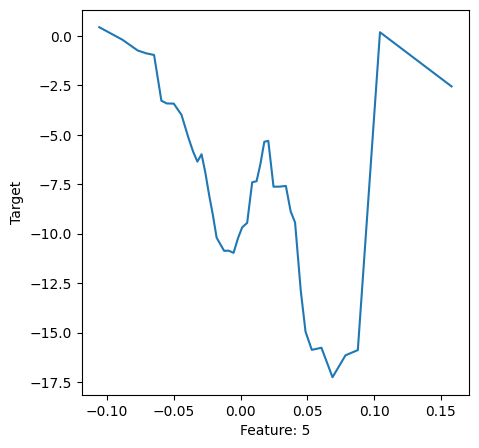

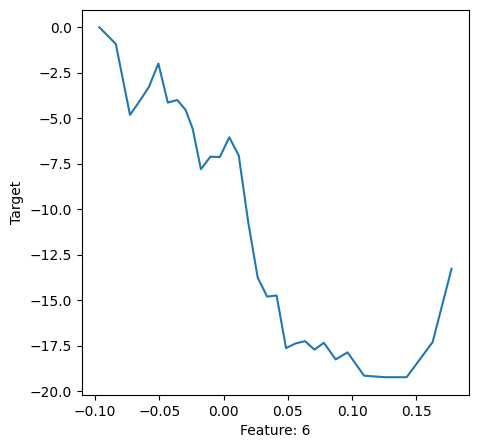

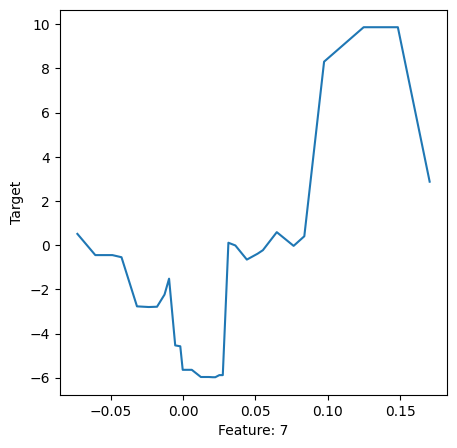

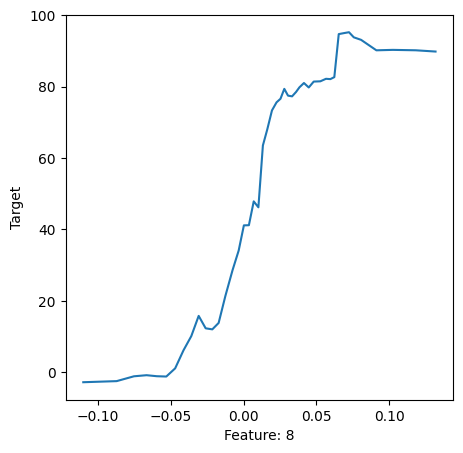

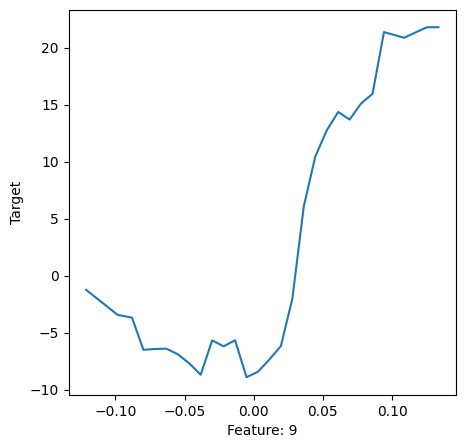

In [151]:
for feature in features_averages:
    plt.figure(figsize=(5,5))
    predictions = features_averages[feature][0]
    values = features_averages[feature][1]
    
    plt.plot(values, np.cumsum(predictions))
    plt.xlabel(f'Feature: {feature}')
    plt.ylabel('Target')